# [실습] 데이터프레임 집계

1) pandas 라이브러리를 pd 별칭을 주어 불러오세요.

In [2]:
import pandas as pd

2) 다음 경로의 파일을 읽어 graduate 데이터프레임을 만드세요.
- 파일 : 'Graduate_apply.csv'

In [3]:
path = './../00_data/Graduate_apply.csv'
graduate = pd.read_csv(path)
graduate.head()

,admit,gre,gpa,rank
0,0,380,3.61,3
1,1,660,3.67,3
2,1,800,4.00,1
3,1,640,3.19,4
4,0,520,2.93,4


3) 열의 데이터 형식과 값의 개수 등을 확인하세요.

In [4]:
graduate.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   admit   400 non-null    int64  
 1   gre     400 non-null    int64  
 2   gpa     400 non-null    float64
 3   rank    400 non-null    int64  
dtypes: float64(1), int64(3)
memory usage: 12.6 KB


4) 기초통계정보를 확인하세요.

In [5]:
graduate.describe()

,admit,gre,gpa,rank
count,400.000000,400.000000,400.000000,400.00000
mean,0.317500,587.700000,3.389900,2.48500
std,0.466087,115.516536,0.380567,0.94446
min,0.000000,220.000000,2.260000,1.00000
25%,0.000000,520.000000,3.130000,2.00000
50%,0.000000,580.000000,3.395000,2.00000
75%,1.000000,660.000000,3.670000,3.00000
max,1.000000,800.000000,4.000000,4.00000


5) gre 중앙값을 확인하세요.

In [6]:
graduate['gre'].median()

np.float64(580.0)

6) rank별 gre 중앙값을 집계하여 tmp 데이터프레임으로 선언하고 확인하세요.

In [7]:
temp = graduate.groupby('rank')[['gre']].median()
temp

,gre
rank,
1,600.0
2,600.0
3,580.0
4,560.0


7) rank별 gpa 평균을 집계하여 tmp 데이터프레임으로 선언하고 확인하세요.

In [8]:
tmp = graduate.groupby('rank')[['gpa']].mean()
tmp

,gpa
rank,
1,3.453115
2,3.361656
3,3.432893
4,3.318358


8) rank, admit별 gpa 평균을 집계하여 tmp 데이터프레임으로 선언하고 확인하세요.

In [9]:
tmp = graduate.groupby(['rank', 'admit'])[['gpa']].mean()
tmp

gpa
rank admit          
1    0      3.345714
     1      3.544242
2    0      3.316598
     1      3.442593
3    0      3.402258
     1      3.534643
4    0      3.291455
     1      3.441667

9) rank별 합격자 수를 집계하여 tmp 데이터프레임으로 선언하고 막대 그래프로 시각화하여 확인하세요.

In [14]:
graduate.head()
tmp = graduate.groupby('rank')[['admit']].sum()
tmp

,admit
rank,
1,33
2,54
3,28
4,12


<Axes: xlabel='rank'>

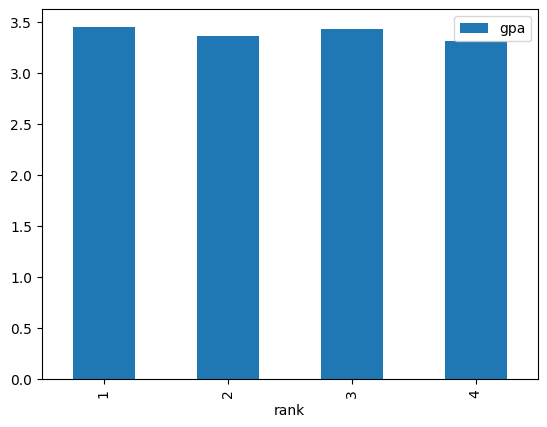

In [13]:
tmp.plot(kind='bar')

10) rank별 합격률을 집계하여 tmp 데이터프레임으로 선언하고 막대그래프로 시각화해 확인하세요.

- admit 열 값이 0, 1이므로 admit 열 평균이 합격률이 됨

In [16]:
tmp = graduate.groupby(['rank'])[['admit']].mean()
tmp

,admit
rank,
1,0.540984
2,0.357616
3,0.231405
4,0.179104


<Axes: xlabel='rank'>

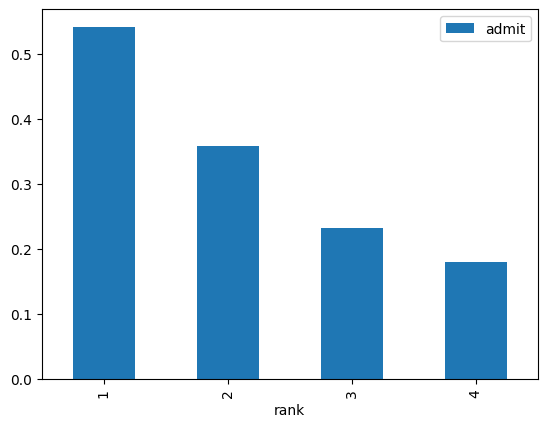

In [17]:
tmp.plot(kind='bar')